Running BFS...
BFS: Exploring cell (1, 1) — distance to goal: 38 steps
BFS: Exploring cell (2, 1) — distance to goal: 37 steps
BFS: Exploring cell (3, 1) — distance to goal: 36 steps
BFS: Exploring cell (3, 2) — distance to goal: 35 steps
BFS: Exploring cell (3, 3) — distance to goal: 34 steps
BFS: Exploring cell (3, 4) — distance to goal: 33 steps
BFS: Exploring cell (4, 4) — distance to goal: 32 steps
BFS: Exploring cell (3, 5) — distance to goal: 32 steps
BFS: Exploring cell (5, 4) — distance to goal: 31 steps
BFS: Exploring cell (4, 5) — distance to goal: 31 steps
BFS: Exploring cell (6, 4) — distance to goal: 30 steps
BFS: Exploring cell (5, 5) — distance to goal: 30 steps
BFS: Exploring cell (4, 6) — distance to goal: 30 steps
BFS: Exploring cell (6, 5) — distance to goal: 29 steps
BFS: Exploring cell (5, 6) — distance to goal: 29 steps
BFS: Exploring cell (4, 7) — distance to goal: 29 steps
BFS: Exploring cell (6, 6) — distance to goal: 28 steps
BFS: Exploring cell (5, 7) — dist

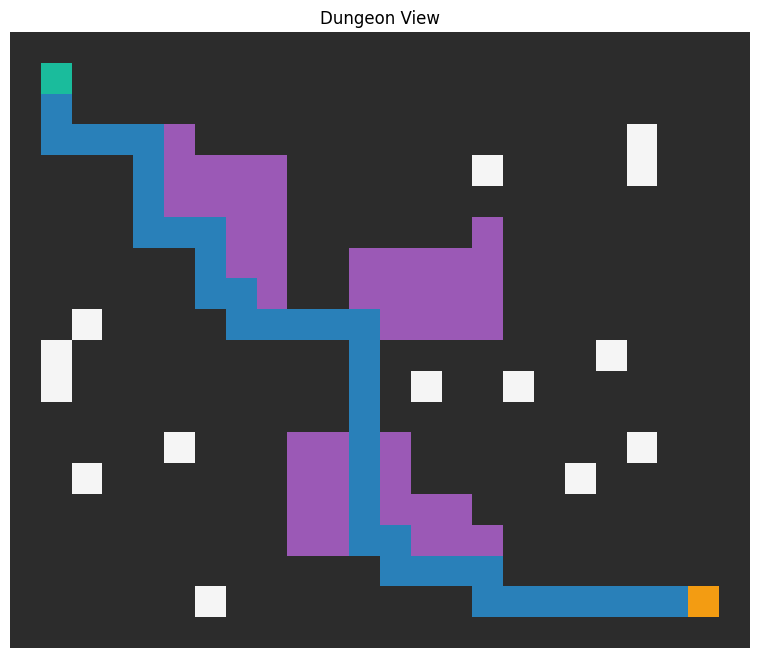

BFS Nodes Explored: 84, Path Length: 39
Running DFS...
DFS: Exploring cell (1, 1) — depth: 0
DFS: Exploring cell (2, 1) — depth: 1
DFS: Exploring cell (3, 1) — depth: 2
DFS: Exploring cell (3, 2) — depth: 3
DFS: Exploring cell (3, 3) — depth: 4
DFS: Exploring cell (3, 4) — depth: 5
DFS: Exploring cell (3, 5) — depth: 6
DFS: Exploring cell (4, 5) — depth: 7
DFS: Exploring cell (4, 6) — depth: 8
DFS: Exploring cell (4, 7) — depth: 9
DFS: Exploring cell (4, 8) — depth: 10
DFS: Exploring cell (5, 8) — depth: 11
DFS: Exploring cell (6, 8) — depth: 12
DFS: Exploring cell (6, 7) — depth: 13
DFS: Exploring cell (6, 6) — depth: 14
DFS: Exploring cell (6, 5) — depth: 15
DFS: Exploring cell (6, 4) — depth: 16
DFS: Exploring cell (5, 4) — depth: 17
DFS: Exploring cell (7, 6) — depth: 15
DFS: Exploring cell (8, 6) — depth: 16
DFS: Exploring cell (8, 7) — depth: 17
DFS: Exploring cell (8, 8) — depth: 18
DFS: Exploring cell (9, 8) — depth: 19
DFS: Exploring cell (9, 9) — depth: 20
DFS: Exploring cell

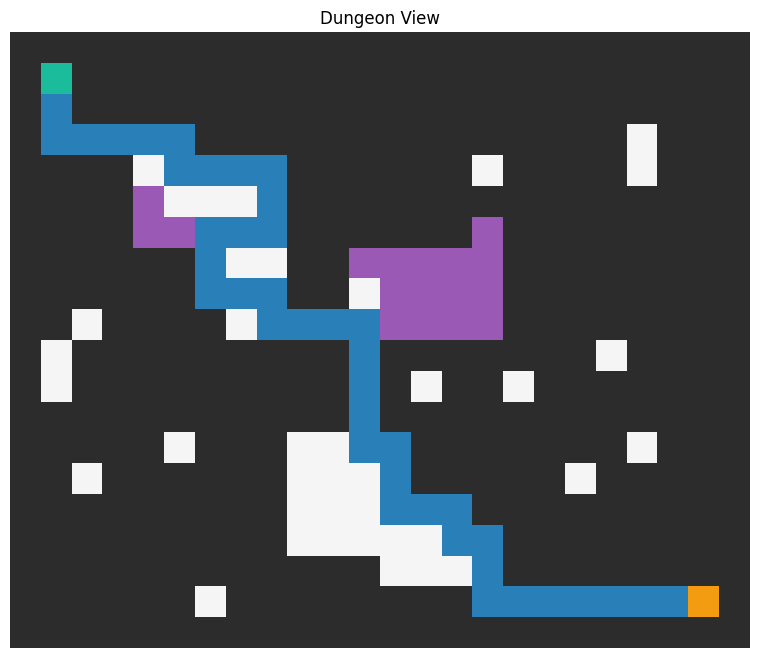

DFS Nodes Explored: 60, Path Length: 43


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import deque

def manhattan(cell1, cell2):
    """
    Calculates the Manhattan distance between two cells.
    
    Args:
        cell1: Tuple (row, col) of the first cell
        cell2: Tuple (row, col) of the second cell
    Returns:
        Integer representing Manhattan distance
    """
    return abs(cell1[0] - cell2[0]) + abs(cell1[1] - cell2[1])

def get_neighbors(grid, row, col):
    """
    Returns list of valid walkable neighboring cells (4-directional).
    Only returns cells that are within grid bounds and are floor cells (value=1).
    
    Args:
        grid: 2D list representing dungeon (0=wall, 1=floor)
        row: current cell row index
        col: current cell column index
    Returns:
        List of (row, col) tuples for valid neighbors
    """
    # Define 4-directional movement: up, down, left, right
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    neighbors = []
    
    for dr, dc in directions:
        new_row, new_col = row + dr, col + dc
        # Check bounds and walkability
        if (0 <= new_row < len(grid) and 
            0 <= new_col < len(grid[0]) and 
            grid[new_row][new_col] == 1):
            neighbors.append((new_row, new_col))
    
    return neighbors

def reconstruct_path(parent, start, goal):
    """
    Reconstructs the path from start to goal using the parent dictionary.
    
    Args:
        parent: Dictionary mapping each cell to its parent
        start: Tuple (row, col) for start position
        goal: Tuple (row, col) for goal position
    Returns:
        List of (row, col) tuples representing the path
    """
    path = []
    current = goal
    while current != start:
        path.append(current)
        current = parent[current]
    path.append(start)
    path.reverse()
    return path

def bfs_reachable(grid, start, goal):
    """
    Quick BFS to check if the goal is reachable from the start.
    Used mainly by CSP for validation.
    
    Args:
        grid: 2D list representing dungeon
        start: Tuple (row, col) for start position
        goal: Tuple (row, col) for goal position
    Returns:
        Boolean, True if path exists, False otherwise
    """
    queue = deque([start])
    visited = {start}
    
    while queue:
        r, c = queue.popleft()
        if (r, c) == goal:
            return True
            
        for neighbor in get_neighbors(grid, r, c):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                
    return False

def generate_dungeon(rows=20, cols=24, start=(1,1), goal=(18,22)):
    """
    Generates a randomized dungeon ensuring a path exists from start to goal.
    
    Args:
        rows: Height of grid
        cols: Width of grid
        start: Start cell tuple
        goal: Goal cell tuple
    Returns:
        2D list representing the dungeon
    """
    while True:
        # Step 1: Initialize all cells as walls (0)
        grid = [[0 for _ in range(cols)] for _ in range(rows)]
        
        # Step 2: Carve a winding corridor from Start to Goal
        r, c = start
        grid[r][c] = 1
        while (r, c) != goal:
            if r < goal[0] and c < goal[1]:
                if random.random() < 0.5:
                    r += 1
                else:
                    c += 1
            elif r < goal[0]:
                r += 1
            elif c < goal[1]:
                c += 1
            grid[r][c] = 1
            
        # Step 3: Carve 5-8 random rectangular rooms
        num_rooms = random.randint(5, 8)
        for _ in range(num_rooms):
            room_h = random.randint(3, 5)
            room_w = random.randint(3, 5)
            room_r = random.randint(1, rows - room_h - 1)
            room_c = random.randint(1, cols - room_w - 1)
            
            for i in range(room_r, room_r + room_h):
                for j in range(room_c, room_c + room_w):
                    grid[i][j] = 1
                    
        # Step 4: Add random horizontal + vertical corridors
        for _ in range(rows):
            r = random.randint(1, rows - 2)
            c = random.randint(1, cols - 2)
            if grid[r][c] == 0:
                grid[r][c] = 1
                
        # Step 5: Validate using BFS
        if bfs_reachable(grid, start, goal):
            return grid
        # Step 6: If path broken, loop and retry

def display_grid(grid, visited=set(), path=[], start=(1,1), goal=(18,22), enemy=None, clusters=None):
    """
    Displays the grid using matplotlib.
    """
    rows = len(grid)
    cols = len(grid[0])
    
    # Colors
    # 0 = Wall: #2C2C2C, 1 = Floor: #F5F5F5, 2 = Visited: #9B59B6, 3 = Path: #2980B9
    # 4 = Start: #1ABC9C, 5 = Goal: #F39C12
    display_data = np.zeros((rows, cols, 3))
    
    for r in range(rows):
        for c in range(cols):
            if grid[r][c] == 0:
                display_data[r, c] = [44/255, 44/255, 44/255] # Wall
            else:
                display_data[r, c] = [245/255, 245/255, 245/255] # Floor
                
            if (r, c) in visited:
                display_data[r, c] = [155/255, 89/255, 182/255] # Visited
            if (r, c) in path:
                display_data[r, c] = [41/255, 128/255, 185/255] # Final Path
                
    # Start and Goal Overrides
    display_data[start[0], start[1]] = [26/255, 188/255, 156/255]
    display_data[goal[0], goal[1]] = [243/255, 156/255, 18/255]
    
    plt.figure(figsize=(10, 8))
    plt.imshow(display_data)
    plt.title("Dungeon View")
    plt.axis('off')
    plt.show()

def bfs(grid, start, goal):
    """
    Breadth-First Search — finds shortest path using FIFO Queue.
    Explores level by level. Guaranteed optimal.
    Returns: (path, visited_order, nodes_explored)
    """
    queue = deque([start])
    visited = {start}
    parent = {start: None}
    visited_order = []
    
    while queue:
        cell = queue.popleft()
        visited_order.append(cell)
        r, c = cell
        dist = manhattan(cell, goal)
        print(f"BFS: Exploring cell ({r}, {c}) — distance to goal: {dist} steps")
        
        if cell == goal:
            path = reconstruct_path(parent, start, goal)
            return path, visited_order, len(visited_order)
        
        for neighbor in get_neighbors(grid, r, c):
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = cell
                queue.append(neighbor)
    
    return [], visited_order, len(visited_order)

def dfs(grid, start, goal):
    """
    Depth-First Search — explores deep using LIFO Stack.
    Finds a path but NOT guaranteed shortest.
    Returns: (path, visited_order, nodes_explored)
    """
    stack = [start]
    visited = {start}
    parent = {start: None}
    visited_order = []
    depth_map = {start: 0}
    
    while stack:
        cell = stack.pop()
        visited_order.append(cell)
        r, c = cell
        depth = depth_map[cell]
        print(f"DFS: Exploring cell ({r}, {c}) — depth: {depth}")
        
        if cell == goal:
            path = reconstruct_path(parent, start, goal)
            return path, visited_order, len(visited_order)
        
        for neighbor in get_neighbors(grid, r, c):
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = cell
                depth_map[neighbor] = depth + 1
                stack.append(neighbor)
    
    return [], visited_order, len(visited_order)

# Test Runner Part 1
start_cell, goal_cell = (1, 1), (18, 22)
dungeon = generate_dungeon(20, 24, start_cell, goal_cell)

print("Running BFS...")
bfs_path, bfs_visited, bfs_nodes = bfs(dungeon, start_cell, goal_cell)
display_grid(dungeon, visited=set(bfs_visited), path=bfs_path, start=start_cell, goal=goal_cell)
print(f"BFS Nodes Explored: {bfs_nodes}, Path Length: {len(bfs_path)}")

print("Running DFS...")
dfs_path, dfs_visited, dfs_nodes = dfs(dungeon, start_cell, goal_cell)
display_grid(dungeon, visited=set(dfs_visited), path=dfs_path, start=start_cell, goal=goal_cell)
print(f"DFS Nodes Explored: {dfs_nodes}, Path Length: {len(dfs_path)}")